# Appendices - Data-Driven Prediction of DC Current in an Inverter-Free Photovoltaic Battery System for Telecommunications Antenna Applications

## Model creation in EvalML and PyCaret

## Import of libraries

In [89]:
from evalml.automl import AutoMLSearch
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from evalml.preprocessing import split_data
from woodwork.logical_types import Categorical, Double, Integer
from evalml.utils import infer_feature_types
import evalml
from pycaret.regression import setup, compare_models, pull


## Constants

In [90]:
# ============ PARAMETERS ============
MODELS_IO_FILE = "./resources/models_io.pkl"
TARGET_VAR = "Core Sum of Load Current Avg"
FILE_PATH = "HOURLY_DEC_2025_v4.csv"

# Upload dataset

In [91]:
# ============ LOAD DATA ============
df = pd.read_csv('HOURLY_DEC_2025_v5.csv')

# Make sure we have a datetime column
if "date" not in df.columns:
    df.rename(columns={df.columns[0]: "date"}, inplace=True)

df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# Preview target variable and features

In [92]:
import os
import pickle as pkl

# Create folder if it doesn't exist
os.makedirs("./resources", exist_ok=True)

# Features: all other columns except target
features = [col for col in df.columns if col != TARGET_VAR]
features
# Save to dictionary with “target” as the key
models_io = {TARGET_VAR: features}

# Save as a .pkl file
MODELS_IO_FILE = "./resources/models_io.pkl"
with open(MODELS_IO_FILE, "wb") as f:
    pkl.dump(models_io, f)

print("✅ models_io.pkl created successfully")
print(f"Target: {TARGET_VAR}")
print("Features:", features)

✅ models_io.pkl created successfully
Target: Core Sum of Load Current Avg
Features: ['day', 'hour', 'dayofweek', 'dayofyear', 'weekofyear', 'Core Ess Current Avg', 'Core Ess Brick Min Voltage Avg', 'Core System Ambient Temp Avg', 'Core System Link Voltage Avg', 'Core System Humidity Avg', 'Core Mppt Output Current Avg', 'Core Mppt Array Voltage Avg', 'Core Ess Max Soc Avg', 'Metric Solar Energy Provided Asum', 'Metric Load Energy Used Asum', 'Metric Load Measurement Avg', 'Metric Battery Energy Provided Asum', 'Metric Battery Energy Consumed Asum', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'direct_normal_irradiance (W/m²)']


# Create time features

In [93]:
# ============ CREATE TIME FEATURES ============
def create_time_features(df):
    df = df.copy()
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["dayofweek"] = df.index.dayofweek
    df["dayofyear"] = df.index.dayofyear
    df["weekofyear"] = df.index.isocalendar().week.astype(int)
    df["quarter"] = df.index.quarter
    return df

#inputs and outputs of the model
models_io = pkl.load(open(MODELS_IO_FILE, "rb"))
models_io_target = models_io[TARGET_VAR]

# Lista de columnas a eliminar
cols_to_remove = [
    "year", "month", "day", "hour", "minute",
    "dayofyear", "weekofyear", "dayofweek",
    "hourofday", "device_id"
]

# Remover solo si existen
for col in cols_to_remove:
    if col in models_io_target:
        models_io_target.remove(col)

# Guardar nuevamente el archivo actualizado
with open(MODELS_IO_FILE, "wb") as f:
    pkl.dump(models_io, f)

print("✅ Columnas eliminadas correctamente")
print("Features finales:", models_io_target[:20], "...")

df

✅ Columnas eliminadas correctamente
Features finales: ['Core Ess Current Avg', 'Core Ess Brick Min Voltage Avg', 'Core System Ambient Temp Avg', 'Core System Link Voltage Avg', 'Core System Humidity Avg', 'Core Mppt Output Current Avg', 'Core Mppt Array Voltage Avg', 'Core Ess Max Soc Avg', 'Metric Solar Energy Provided Asum', 'Metric Load Energy Used Asum', 'Metric Load Measurement Avg', 'Metric Battery Energy Provided Asum', 'Metric Battery Energy Consumed Asum', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'direct_normal_irradiance (W/m²)'] ...


,day,hour,dayofweek,dayofyear,weekofyear,Core Ess Current Avg,Core Ess Brick Min Voltage Avg,Core System Ambient Temp Avg,Core System Link Voltage Avg,Core System Humidity Avg,...,Core Ess Max Soc Avg,Metric Solar Energy Provided Asum,Metric Load Energy Used Asum,Metric Load Measurement Avg,Metric Battery Energy Provided Asum,Metric Battery Energy Consumed Asum,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),direct_normal_irradiance (W/m²)
date,,,,,,,,,,,,,,,,,,,,,
2025-12-01 00:00:00,1,0,0,335,49,-14.3595,3.616188,33.326485,50.943000,39.154133,...,42.880720,0.000000,0.577963,0.720474,0.585842,0.0,23.4,96,6.0,0.0
2025-12-01 01:00:00,1,1,0,335,49,-11.6595,3.602199,33.375144,50.676000,39.263263,...,39.238386,0.000000,0.501509,0.576214,0.507521,0.0,23.0,98,0.2,0.0
2025-12-01 02:00:00,1,2,0,335,49,-11.0510,3.583333,33.426357,50.434501,39.613127,...,36.624231,0.000000,0.468672,0.545367,0.475079,0.0,23.5,97,0.2,0.0
2025-12-01 03:00:00,1,3,0,335,49,-11.1445,3.563503,33.364899,50.163001,39.738514,...,33.794254,0.000000,0.464082,0.562909,0.472124,0.0,23.4,98,0.0,0.0
2025-12-01 04:00:00,1,4,0,335,49,-12.6040,3.533876,33.382826,49.840501,39.692853,...,30.552710,0.000000,0.480831,0.625476,0.489115,0.0,23.3,97,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:59:00,31,19,2,365,1,-19.2065,3.865988,34.775913,54.303001,31.002152,...,69.377845,0.000803,1.036469,1.040472,1.042947,0.0,27.9,80,0.0,0.0
2025-12-31 19:59:00,31,20,3,365,1,-20.0155,3.812481,33.259907,53.709001,36.946529,...,64.898925,0.000000,1.103115,1.067151,1.110846,0.0,28.5,76,0.0,0.0
2025-12-31 20:59:00,31,21,3,365,1,-19.3930,3.745804,33.286793,52.762500,37.954440,...,57.802868,0.000000,1.062494,1.016439,1.068524,0.0,27.0,83,0.4,0.0


In [94]:
# Keep target + add time features
df_period = df[models_io_target + [TARGET_VAR]]
df_period = df_period.dropna(subset=TARGET_VAR)
df_period = df_period.apply(pd.to_numeric, errors="coerce")
df_period

,Core Ess Current Avg,Core Ess Brick Min Voltage Avg,Core System Ambient Temp Avg,Core System Link Voltage Avg,Core System Humidity Avg,Core Mppt Output Current Avg,Core Mppt Array Voltage Avg,Core Ess Max Soc Avg,Metric Solar Energy Provided Asum,Metric Load Energy Used Asum,Metric Load Measurement Avg,Metric Battery Energy Provided Asum,Metric Battery Energy Consumed Asum,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),direct_normal_irradiance (W/m²),Core Sum of Load Current Avg
date,,,,,,,,,,,,,,,,,,
2025-12-01 00:00:00,-14.3595,3.616188,33.326485,50.943000,39.154133,0.000000,0.319977,42.880720,0.000000,0.577963,0.720474,0.585842,0.0,23.4,96,6.0,0.0,-14.1340
2025-12-01 01:00:00,-11.6595,3.602199,33.375144,50.676000,39.263263,0.000000,0.363922,39.238386,0.000000,0.501509,0.576214,0.507521,0.0,23.0,98,0.2,0.0,-11.3875
2025-12-01 02:00:00,-11.0510,3.583333,33.426357,50.434501,39.613127,0.000000,0.168915,36.624231,0.000000,0.468672,0.545367,0.475079,0.0,23.5,97,0.2,0.0,-11.1955
2025-12-01 03:00:00,-11.1445,3.563503,33.364899,50.163001,39.738514,0.000000,0.112610,33.794254,0.000000,0.464082,0.562909,0.472124,0.0,23.4,98,0.0,0.0,-11.1955
2025-12-01 04:00:00,-12.6040,3.533876,33.382826,49.840501,39.692853,0.000000,0.278778,30.552710,0.000000,0.480831,0.625476,0.489115,0.0,23.3,97,0.0,0.0,-12.5450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:59:00,-19.2065,3.865988,34.775913,54.303001,31.002152,0.289307,30.419770,69.377845,0.000803,1.036469,1.040472,1.042947,0.0,27.9,80,0.0,0.0,-19.2030
2025-12-31 19:59:00,-20.0155,3.812481,33.259907,53.709001,36.946529,0.000000,1.159058,64.898925,0.000000,1.103115,1.067151,1.110846,0.0,28.5,76,0.0,0.0,-19.3465
2025-12-31 20:59:00,-19.3930,3.745804,33.286793,52.762500,37.954440,0.000000,1.141205,57.802868,0.000000,1.062494,1.016439,1.068524,0.0,27.0,83,0.4,0.0,-19.3465


# Analysis period

In [95]:
df_period = create_time_features(df_period)

In [96]:
# ============ VISUALIZATION ============
fig = px.line(df_period, title=f"December ({df_period.first_valid_index().strftime('%Y-%m-%d %H:%M')} - {df_period.last_valid_index().strftime('%Y-%m-%d')})")
fig.show()


#fig = px.line(
#    df_period,
#    y=TARGET_VAR,
#    title=f"{TARGET_VAR} ({df.first_valid_index().strftime('%Y-%m-%d %H:%M')} - {df.last_valid_index().strftime('%Y-%m-%d %H:%M')})"
#)
#fig.show()

In [97]:
X_period, y_period = df_period.drop(TARGET_VAR, axis=1), df_period[TARGET_VAR]


# Set feature types

In [98]:
# Set feature types
X = infer_feature_types(
    X_period,
    feature_types={
        col: "Double"
        if col not in ["year","month","day","hour","minute","dayofweek","dayofyear","weekofyear","quarter"]
        else "Integer"
        for col in X_period.columns
    },
)


# Train test split

In [99]:
# ============ TRAIN/TEST SPLIT ============
TEST_SIZE = 0.3
X_train_period, X_test_period, y_train_period, y_test_period = evalml.preprocessing.split_data(X_period, y_period, problem_type="regression", test_size=TEST_SIZE)
print(
    f"Training Samples: {len(X_train_period)} | {X_train_period.index.min()} - {X_train_period.index.max()}"
)
print(f"Test Samples: {len(X_test_period)} | {X_test_period.index.min()} - {X_test_period.index.max()}")
X_train_period
X_test_period

Training Samples: 520 | 2025-12-01 00:00:00 - 2025-12-31 21:59:00
Test Samples: 224 | 2025-12-01 01:00:00 - 2025-12-31 22:59:00


,Core Ess Current Avg,Core Ess Brick Min Voltage Avg,Core System Ambient Temp Avg,Core System Link Voltage Avg,Core System Humidity Avg,Core Mppt Output Current Avg,Core Mppt Array Voltage Avg,Core Ess Max Soc Avg,Metric Solar Energy Provided Asum,Metric Load Energy Used Asum,...,direct_normal_irradiance (W/m²),year,month,day,hour,minute,dayofweek,dayofyear,weekofyear,quarter
date,,,,,,,,,,,,,,,,,,,,,
2025-12-29 12:59:00,-3.91700,4.009288,37.417456,56.443501,31.102332,14.251709,90.348817,84.593068,1.182996,0.963197,...,846.0,2025,12,29,12,59,0,363,1,4
2025-12-22 08:59:00,75.14800,3.788286,33.903950,53.715001,39.130285,66.676025,85.928193,62.973299,3.737768,0.474641,...,757.6,2025,12,22,8,59,0,356,52,4
2025-12-01 14:00:00,59.35000,3.898745,33.918051,54.745500,35.934962,37.681885,47.930603,71.542832,3.258939,0.669754,...,351.1,2025,12,1,14,0,0,335,49,4
2025-12-02 07:00:00,6.78750,3.407078,29.097427,47.836500,49.977418,5.207520,79.767610,11.574321,0.073108,0.000000,...,110.9,2025,12,2,7,0,1,336,49,4
2025-12-07 12:59:00,2.27500,4.026630,35.878357,56.526001,33.462570,18.898926,91.595764,85.235883,1.095582,0.864316,...,683.1,2025,12,7,12,59,6,341,49,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-12 01:59:00,-11.68900,3.495304,33.052483,49.048500,36.323864,0.000000,1.208496,22.395902,0.000000,0.489736,...,0.0,2025,12,12,1,59,4,346,50,4
2025-12-21 18:59:00,-13.07525,3.901152,35.414235,54.819750,31.390185,5.037842,41.963655,73.168479,0.132429,1.496038,...,0.0,2025,12,21,18,59,6,355,51,4
2025-12-22 06:59:00,11.40600,3.421202,29.639011,48.144000,47.391384,7.922364,79.255373,13.517570,0.215933,0.000000,...,161.9,2025,12,22,6,59,0,356,52,4


In [100]:
# ============ TIME-BASED TRAIN/TEST SPLIT ============

split_date = "2025-12-24 00:00:00"

# Training set
X_train_period = X_period.loc[:split_date]
y_train_period = y_period.loc[:split_date]

# Test set
X_test_period = X_period.loc["2025-12-24 01:00:00":]
y_test_period = y_period.loc["2025-12-24 01:00:00":]

print(
    f"Training Samples: {len(X_train_period)} | "
    f"{X_train_period.index.min()} - {X_train_period.index.max()}"
)

print(
    f"Test Samples: {len(X_test_period)} | "
    f"{X_test_period.index.min()} - {X_test_period.index.max()}"
)

Training Samples: 553 | 2025-12-01 00:00:00 - 2025-12-23 23:59:00
Test Samples: 190 | 2025-12-24 01:59:00 - 2025-12-31 22:59:00


# AutoML Training

In [101]:
# ============ AUTOML TRAINING ============
automl = AutoMLSearch(
    X_train=X_train_period,
    y_train=y_train_period,
    problem_type="regression",
    verbose=False
)
automl.search()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000478 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1339
[LightGBM] [Info] Number of data points in the train set: 368, number of used features: 13
[LightGBM] [Info] Start training from score -13.651684
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

{1: {'Random Forest Regressor w/ Imputer + RF Regressor Select From Model': 2.9026215076446533,
  'Total time of batch': 3.0743634700775146},
 2: {'Extra Trees Regressor w/ Imputer + Select Columns Transformer': 1.076216459274292,
  'XGBoost Regressor w/ Imputer + Select Columns Transformer': 1.7339777946472168,
  'LightGBM Regressor w/ Imputer + Select Columns Transformer': 0.8338055610656738,
  'Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer': 0.8286776542663574,
  'Total time of batch': 5.085914373397827}}

# Evaluation and metric calculation

In [102]:
import pandas as pd
import numpy as np
import time
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error,
    mean_absolute_percentage_error
)

# ===============================
# Evaluate AutoML pipelines correctly
# ===============================
results = []

# Access all pipelines from rankings
for i, row in automl.rankings.iterrows():
    
    pipeline_name = row["pipeline_name"]
    
    try:
        start_time = time.time()
        
        # Retrieve pipeline by rank index
        pipeline = automl.get_pipeline(i)
        
        # Fit
        pipeline.fit(X_train_period, y_train_period)
        
        # Predict
        y_pred = pipeline.predict(X_test_period)
        
        # Metrics
        mae = mean_absolute_error(y_test_period, y_pred)

        # Naive forecast MAE on training data
        naive_mae = np.mean(
        np.abs(
            y_train_period.values[1:]
            - y_train_period.values[:-1]
            )
        )  

        mase = mae / naive_mae

        mse = mean_squared_error(y_test_period, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_period, y_pred)

        # RMSLE
        y_test_safe = np.maximum(y_test_period, 0)
        y_pred_safe = np.maximum(y_pred, 0)
        rmsle = np.sqrt(mean_squared_log_error(y_test_safe, y_pred_safe))

        # MAPE
        mape = mean_absolute_percentage_error(y_test_period, y_pred) * 100

        elapsed_time = time.time() - start_time

        # Store
        results.append({
            "Model": pipeline_name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "RMSLE": rmsle,
            "MAPE (%)": mape,
            "MASE (%)": mase,
            "TIME (s)": elapsed_time
        })

    except Exception as e:
        print(f"Skipping {pipeline_name}: {e}")

# Results DataFrame
results_df = pd.DataFrame(results)

# Sort best models
results_df = results_df.sort_values(by="RMSE", ascending=True)

# Reset index
results_df.reset_index(drop=True, inplace=True)

print(results_df)

# Optional export
results_df.to_csv("automl_model_comparison.csv", index=False)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000287 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2000
[LightGBM] [Info] Number of data points in the train set: 553, number of used features: 13
[LightGBM] [Info] Start training from score -13.542307
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

# Imputer description

In [103]:
automl.describe_pipeline(5)


***********************************************************************************


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- 
***********************************************************************************


* Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer *


INFO	evalml.pipelines.pipeline_base.describe:logger.py:log_title()- * Elastic Net Regressor w/ Imputer + Standard Scaler + Select Columns Transformer *


***********************************************************************************


...

INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- Cross Validation


----------------


INFO	evalml.automl.automl_search.describe_pipeline:logger.py:log_subtitle()- ----------------


               R2  ExpVariance  MaxError  MedianAE   MSE   MAE  Root Mean Squared Error # Training # Validation
0           0.911        0.913     7.328     0.330 1.869 0.709                    1.367        368          185
1           0.930        0.931     6.225     0.331 1.459 0.667                    1.208        369          184
2           0.951        0.951     5.201     0.368 0.857 0.570                    0.926        369          184
mean        0.931        0.932     6.251     0.343 1.395 0.649                    1.167          -            -
std         0.020        0.019     1.064     0.022 0.509 0.071                    0.224          -            -
coef of var 0.021        0.020     0.170     0.064 0.365 0.110                    0.192          -            -


INFO	evalml.automl.automl_search.describe_pipeline:automl_search.py:describe_pipeline()-                R2  ExpVariance  MaxError  MedianAE   MSE   MAE  Root Mean Squared Error # Training # Validation
0           0.911        0.913     7.328     0.330 1.869 0.709                    1.367        368          185
1           0.930        0.931     6.225     0.331 1.459 0.667                    1.208        369          184
2           0.951        0.951     5.201     0.368 0.857 0.570                    0.926        369          184
mean        0.931        0.932     6.251     0.343 1.395 0.649                    1.167          -            -
std         0.020        0.019     1.064     0.022 0.509 0.071                    0.224          -            -
coef of var 0.021        0.020     0.170     0.064 0.365 0.110                    0.192          -            -


In [104]:
automl = automl.best_pipeline
automl.fit(X_train_period, y_train_period)
automl.score(X_test_period, y_test_period, objectives=["R2"])

OrderedDict([('R2', 0.9749233990430894)])

# Preprocesing imputers

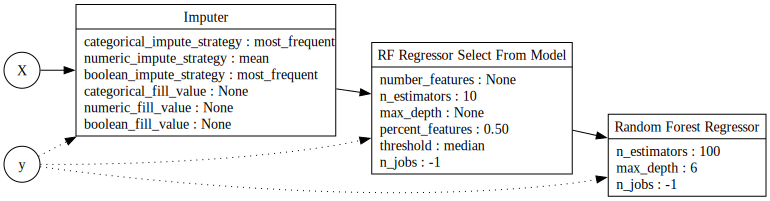

In [105]:
automl.graph()

In [106]:
y_pred_period = automl.predict(X_test_period)
y_pred_period

date
2025-12-24 01:59:00   -11.715025
2025-12-24 02:59:00   -11.196077
2025-12-24 03:59:00   -11.886388
2025-12-24 04:59:00   -11.924944
2025-12-24 05:59:00    -5.253266
                         ...    
2025-12-31 18:59:00   -18.914297
2025-12-31 19:59:00   -19.517544
2025-12-31 20:59:00   -19.197702
2025-12-31 21:59:00   -18.008310
2025-12-31 22:59:00   -16.506190
Name: Core Sum of Load Current Avg, Length: 190, dtype: float64

# Test prediction

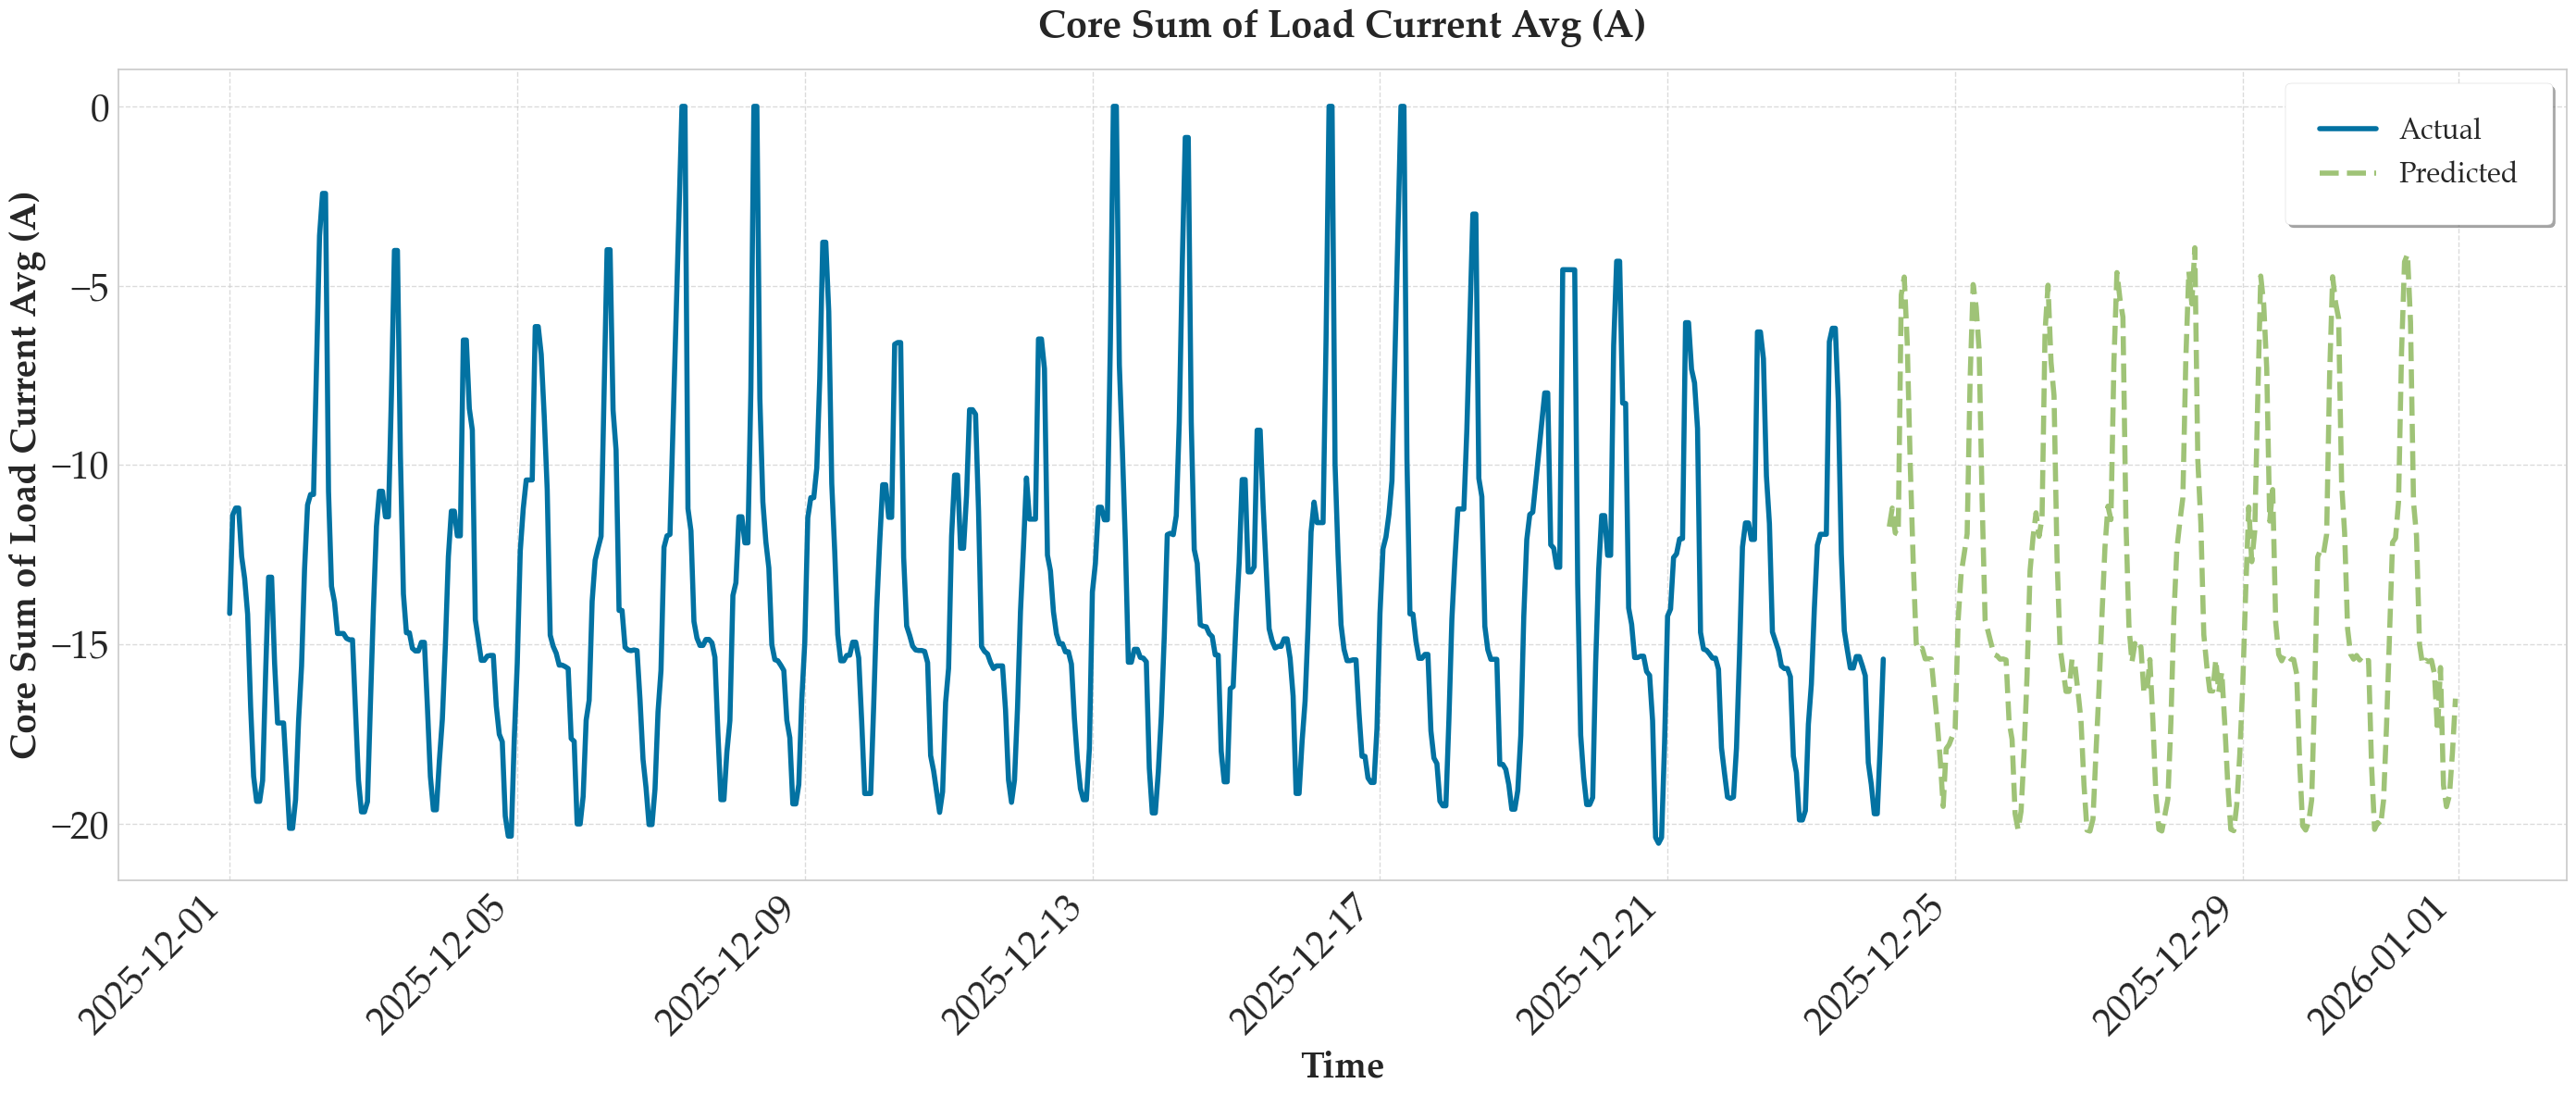

In [107]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Palatino Linotype'  # Works if installed system-wide

# Figure
fig, ax = plt.subplots(figsize=(28, 12))

# Thicker lines
y_train_period.plot(
    ax=ax,
    linewidth=4,
    label="Actual"
)

y_pred_period.plot(
    ax=ax,
    linewidth=4,
    linestyle='--',
    label="Predicted"
)

# Axis labels
ax.set_xlabel(
    "Time",
    fontsize=28,
    fontweight='bold'
)

ax.set_ylabel(
    "Core Sum of Load Current Avg (A)",
    fontsize=28,
    fontweight='bold'
)

# Title
ax.set_title(
    f"Core Sum of Load Current Avg (A)",
    fontsize=30,
    fontweight='bold',
    pad=25
)

# Larger tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=30
)

# Rotate dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Legend bigger
ax.legend(
    loc='upper right',
    fontsize=22,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=1.2
)

# Grid
ax.grid(
    True,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

# Tight layout
plt.tight_layout()

plt.show()

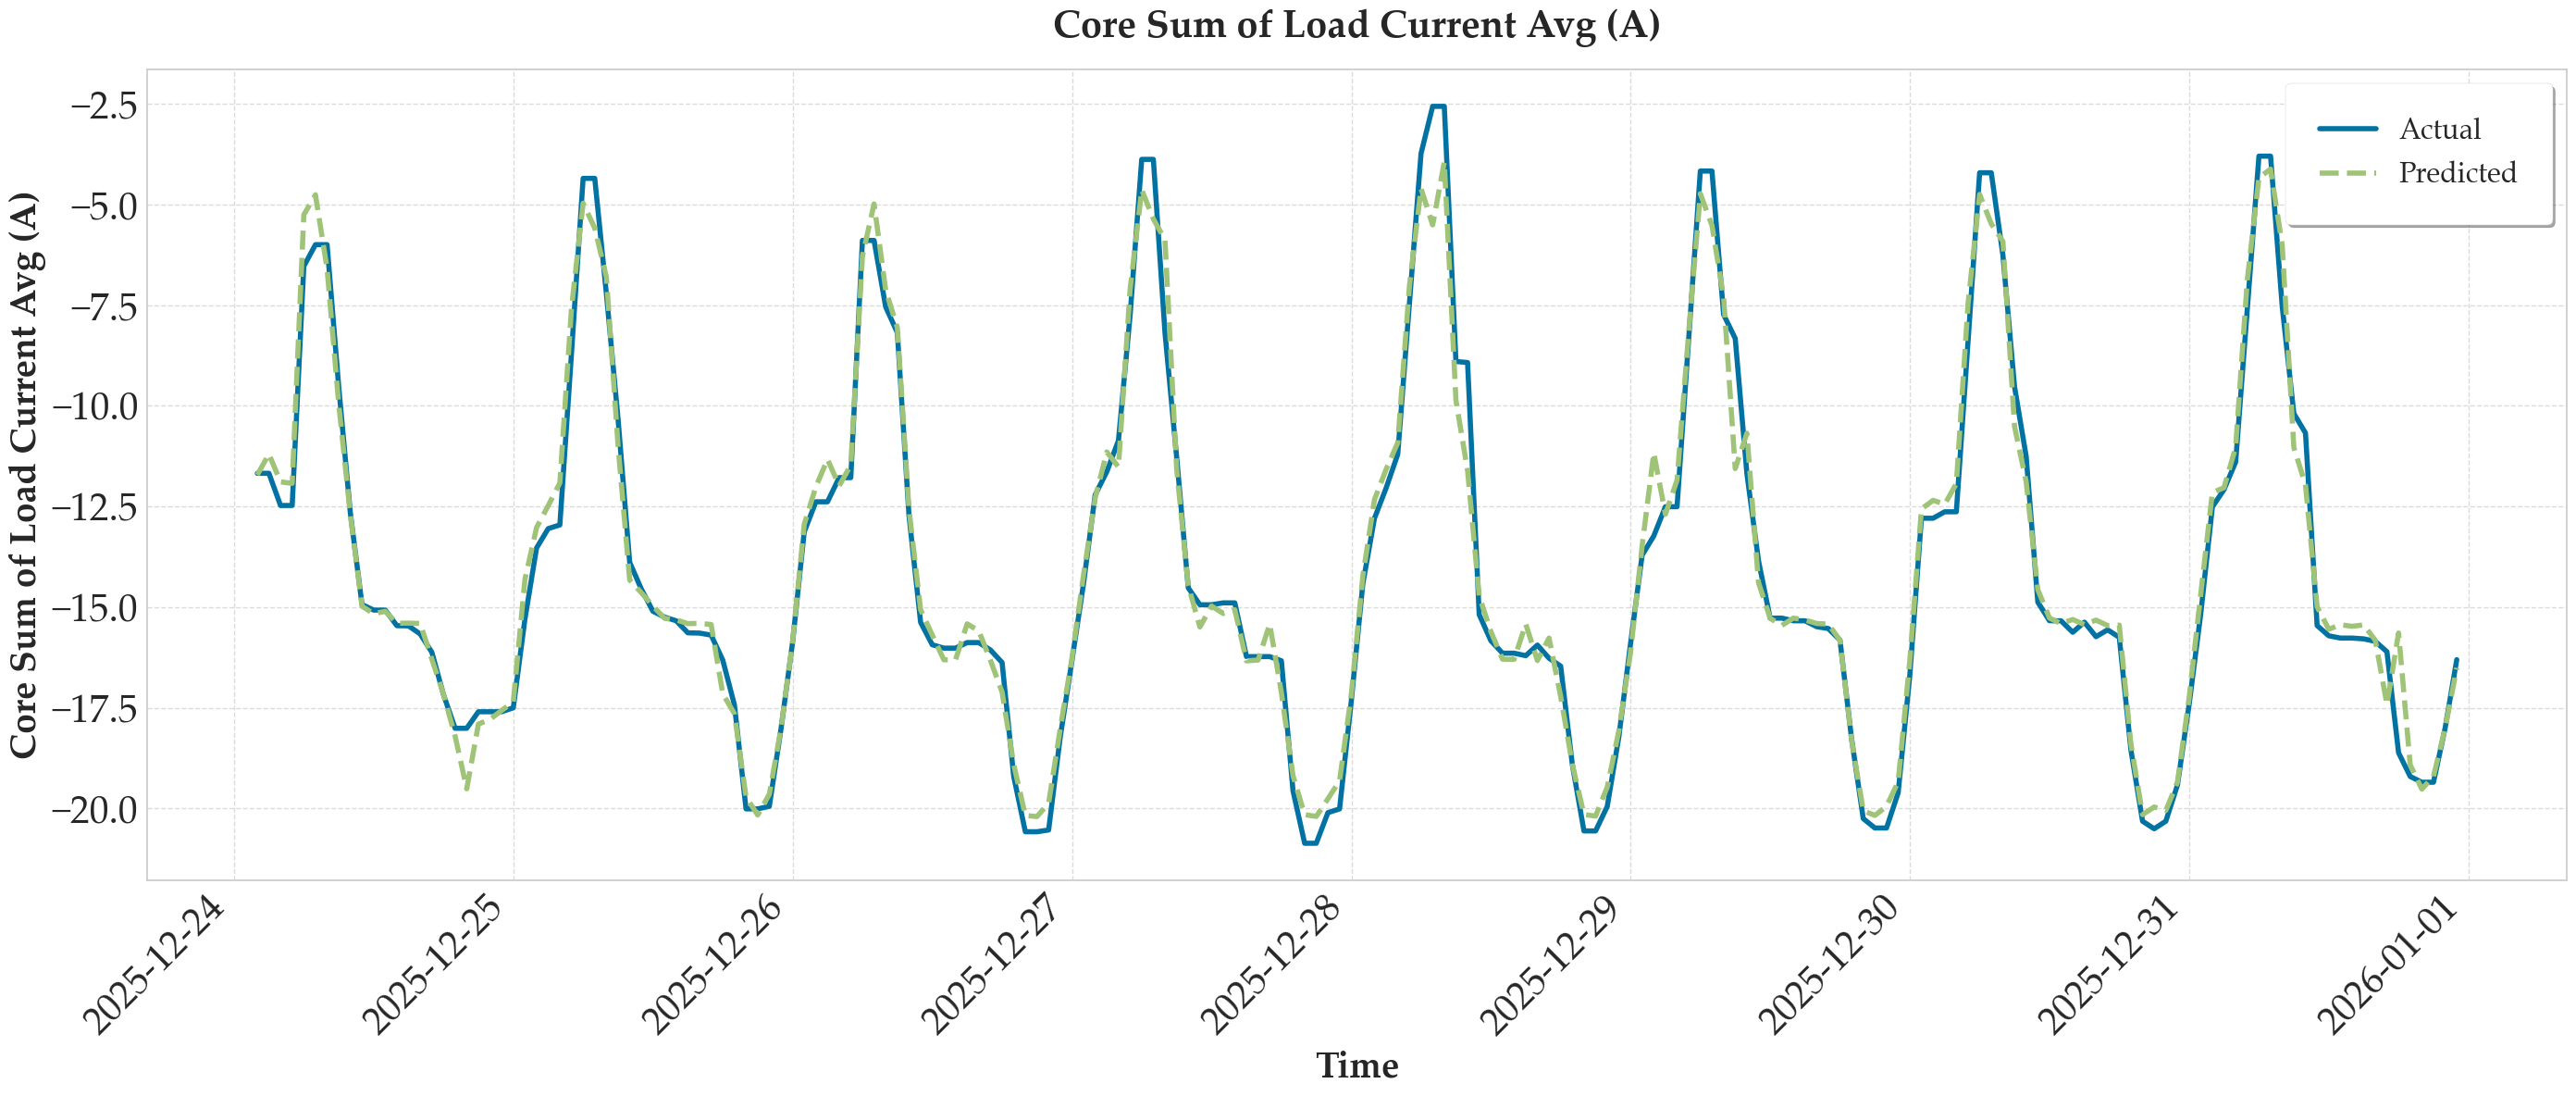

In [108]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Palatino Linotype'  # Works if installed system-wide

# Figure
fig, ax = plt.subplots(figsize=(28, 12))

# Thicker lines
y_test_period.plot(
    ax=ax,
    linewidth=4,
    label="Actual"
)

y_pred_period.plot(
    ax=ax,
    linewidth=4,
    linestyle='--',
    label="Predicted"
)

# Axis labels
ax.set_xlabel(
    "Time",
    fontsize=28,
    fontweight='bold'
)

ax.set_ylabel(
    "Core Sum of Load Current Avg (A)",
    fontsize=28,
    fontweight='bold'
)

# Title
ax.set_title(
    f"Core Sum of Load Current Avg (A)",
    fontsize=30,
    fontweight='bold',
    pad=25
)

# Larger tick labels
ax.tick_params(
    axis='both',
    which='major',
    labelsize=30
)

# Rotate dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

# Legend bigger
ax.legend(
    loc='upper right',
    fontsize=22,
    frameon=True,
    fancybox=True,
    shadow=True,
    borderpad=1.2
)

# Grid
ax.grid(
    True,
    linestyle='--',
    linewidth=1,
    alpha=0.7
)

# Tight layout
plt.tight_layout()

plt.show()

In [109]:
df_period[f"{TARGET_VAR}_pred"] = automl.predict(X_period)
df_period

,Core Ess Current Avg,Core Ess Brick Min Voltage Avg,Core System Ambient Temp Avg,Core System Link Voltage Avg,Core System Humidity Avg,Core Mppt Output Current Avg,Core Mppt Array Voltage Avg,Core Ess Max Soc Avg,Metric Solar Energy Provided Asum,Metric Load Energy Used Asum,...,year,month,day,hour,minute,dayofweek,dayofyear,weekofyear,quarter,Core Sum of Load Current Avg_pred
date,,,,,,,,,,,,,,,,,,,,,
2025-12-01 00:00:00,-14.3595,3.616188,33.326485,50.943000,39.154133,0.000000,0.319977,42.880720,0.000000,0.577963,...,2025,12,1,0,0,0,335,49,4,-14.152341
2025-12-01 01:00:00,-11.6595,3.602199,33.375144,50.676000,39.263263,0.000000,0.363922,39.238386,0.000000,0.501509,...,2025,12,1,1,0,0,335,49,4,-11.723171
2025-12-01 02:00:00,-11.0510,3.583333,33.426357,50.434501,39.613127,0.000000,0.168915,36.624231,0.000000,0.468672,...,2025,12,1,2,0,0,335,49,4,-11.254514
2025-12-01 03:00:00,-11.1445,3.563503,33.364899,50.163001,39.738514,0.000000,0.112610,33.794254,0.000000,0.464082,...,2025,12,1,3,0,0,335,49,4,-11.424974
2025-12-01 04:00:00,-12.6040,3.533876,33.382826,49.840501,39.692853,0.000000,0.278778,30.552710,0.000000,0.480831,...,2025,12,1,4,0,0,335,49,4,-12.087422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 18:59:00,-19.2065,3.865988,34.775913,54.303001,31.002152,0.289307,30.419770,69.377845,0.000803,1.036469,...,2025,12,31,18,59,2,365,1,4,-18.914297
2025-12-31 19:59:00,-20.0155,3.812481,33.259907,53.709001,36.946529,0.000000,1.159058,64.898925,0.000000,1.103115,...,2025,12,31,19,59,2,365,1,4,-19.517544
2025-12-31 20:59:00,-19.3930,3.745804,33.286793,52.762500,37.954440,0.000000,1.141205,57.802868,0.000000,1.062494,...,2025,12,31,20,59,2,365,1,4,-19.197702


In [110]:
fig = px.line(df_period, x=df_period.index, y=[TARGET_VAR, f"{TARGET_VAR}_pred"], title=f"PERIOD: ({df_period.first_valid_index().strftime('%Y-%m-%d')} - {df_period.last_valid_index().strftime('%Y-%m-%d')})")
fig.show()

# Feature Engineering

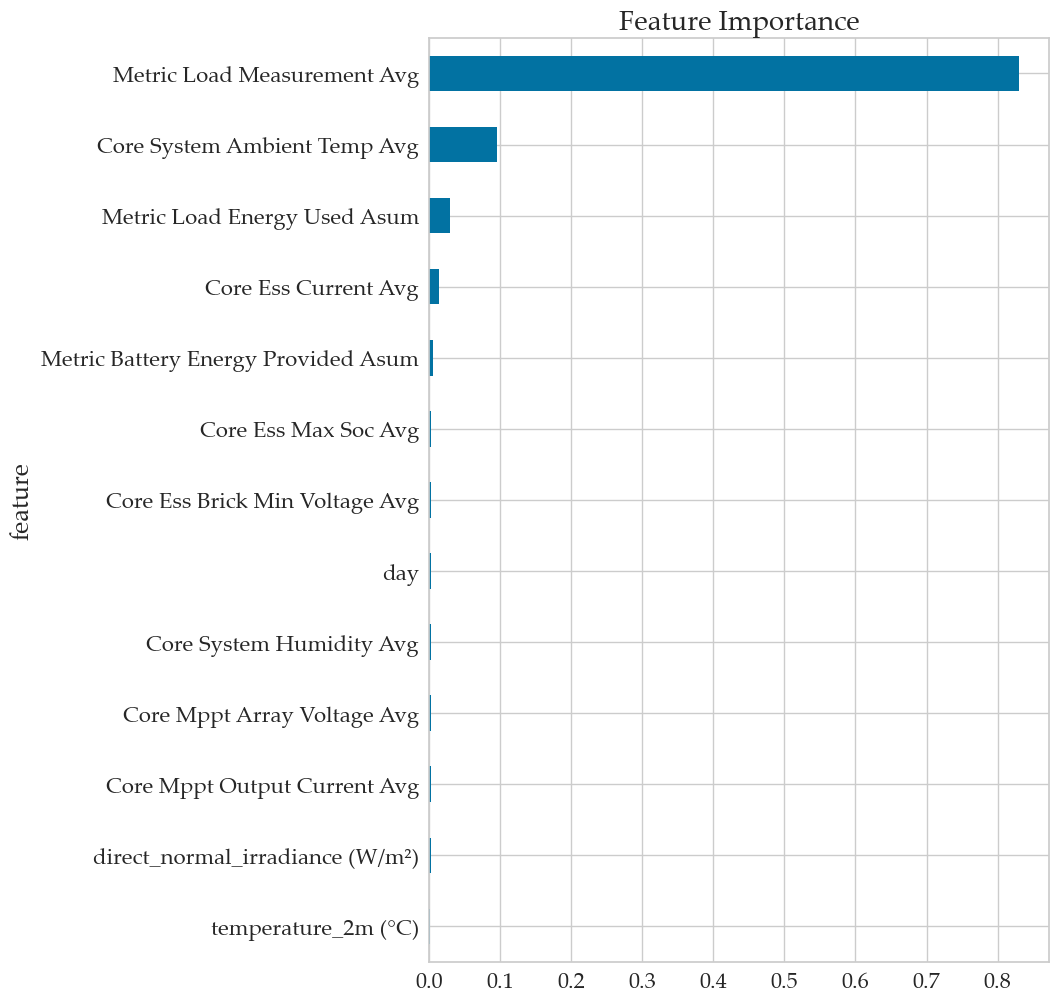

In [111]:
automl.feature_importance.set_index("feature").sort_values(by="importance", ascending=True).plot.barh(figsize=(8, 12), legend=False)
plt.title("Feature Importance")
plt.show()

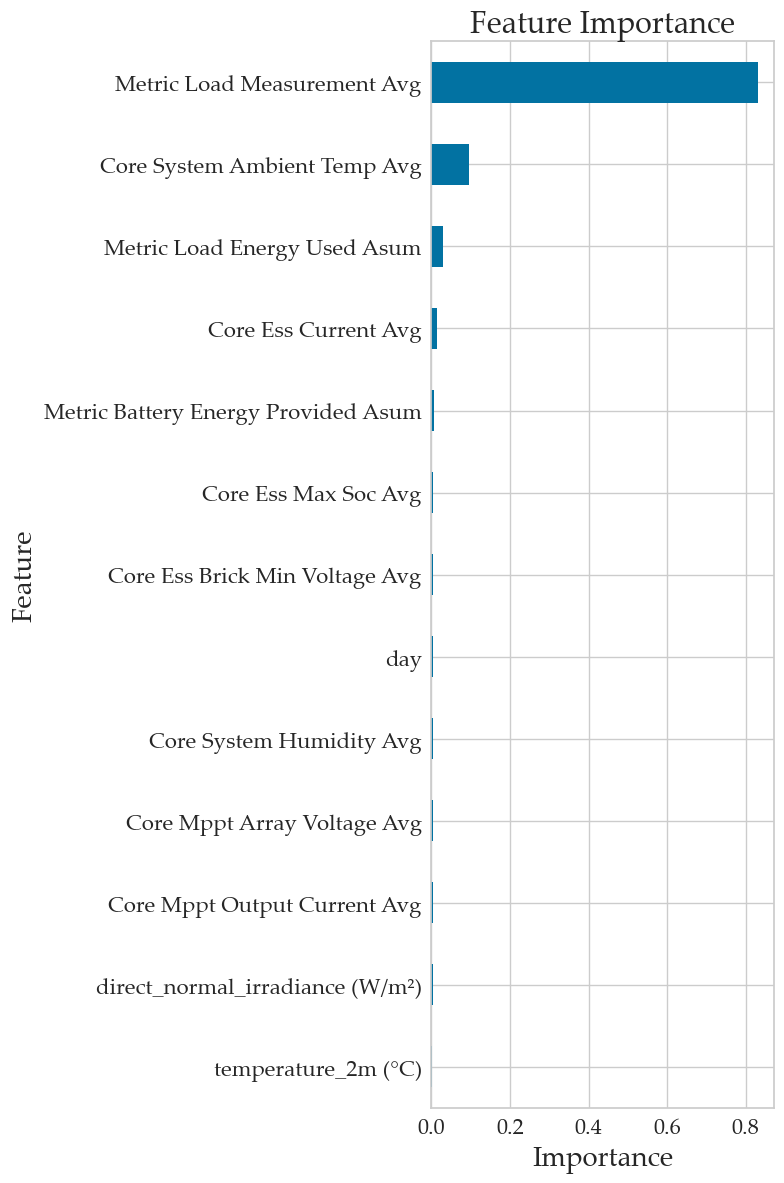

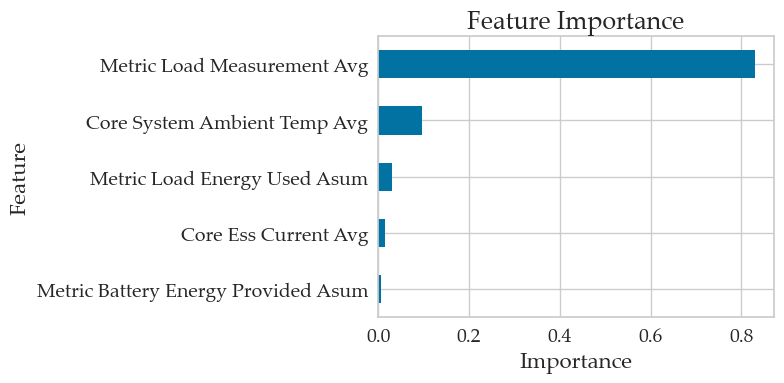

In [112]:
import matplotlib.pyplot as plt

# Configuración global
plt.rcParams["font.family"] = "Palatino Linotype"
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

# Todas las variables
ax = (
    automl.feature_importance
    .set_index("feature")
    .sort_values(by="importance", ascending=True)
    .plot.barh(figsize=(8, 12), legend=False)
)

ax.set_title("Feature Importance", fontsize=22)
ax.set_xlabel("Importance", fontsize=20)
ax.set_ylabel("Feature", fontsize=20)
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.show()


# Top 5 variables
top5 = (
    automl.feature_importance
    .sort_values(by="importance", ascending=False)
    .head(5)
)

ax = (
    top5
    .set_index("feature")
    .sort_values(by="importance", ascending=True)
    .plot.barh(figsize=(8, 4), legend=False)
)

ax.set_title("Feature Importance", fontsize=18)
ax.set_xlabel("Importance", fontsize=16)
ax.set_ylabel("Feature", fontsize=16)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

In [113]:
from evalml.model_understanding import readable_explanation
readable_explanation(
    pipeline=automl,
    X=X_test_period,
    y=y_test_period,
    objective="R2",
    importance_method="feature",
)

Random Forest Regressor: The prediction of Core Sum of Load Current Avg is heavily influenced by Metric Load Measurement Avg, and is somewhat influenced by Core System Ambient Temp Avg.


INFO	evalml.model_understanding.feature_explanations.explain:feature_explanations.py:readable_explanation()- Random Forest Regressor: The prediction of Core Sum of Load Current Avg is heavily influenced by Metric Load Measurement Avg, and is somewhat influenced by Core System Ambient Temp Avg.


# Shap analysis

PermutationExplainer explainer: 125it [03:58,  2.00s/it]                         


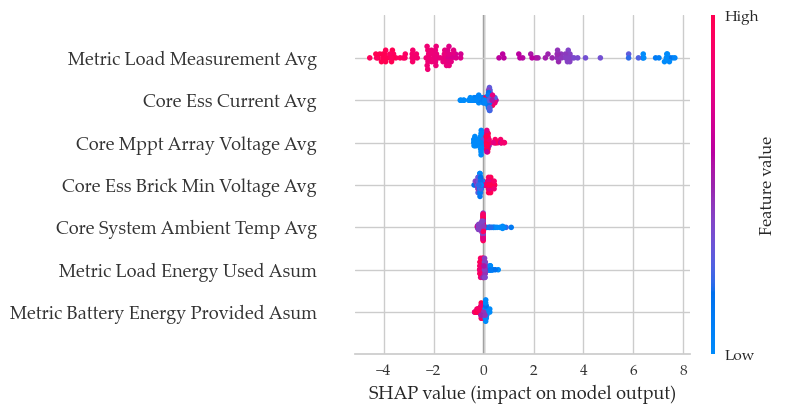

In [114]:
# Import modules
from evalml.pipelines import RegressionPipeline
import shap
import numpy as np

# Split data into train and test sets
df_X = df_period.copy()
df_X = df_X.drop(df_X.filter(like="_pred").columns, axis=1)
df_X = df_X.dropna(axis=1, how="all")
df_X = df_X.fillna(method="bfill")
df_X = df_X.fillna(method="ffill")
# Remove outliers using 3-sigma rule, only with pandas
df_X = df_X[(np.abs(df_X - df_X.mean()) <= (3 * df_X.std())).all(axis=1)]

X, y = df_X.drop(TARGET_VAR, axis=1), df_X[TARGET_VAR]

X_train, X_test, y_train, y_test = evalml.preprocessing.split_data(X, y, problem_type='regression')

# Define a pipeline with an XGBoost regressor component
pipeline = RegressionPipeline(['Imputer', 'XGBoost Regressor'])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Use shap to explain predictions on the test set
explainer = shap.Explainer(pipeline.predict, X_train)
shap_values = explainer(X_test)

# Plot the shap summary plot
shap.summary_plot(shap_values.values, X_test,max_display=7)

# PyCaret modeling

In [115]:
from pycaret.regression import *

# Initialize PyCaret with PCA
reg_setup = setup(
    data=X_train_period.assign(target=y_train_period),  # combine X and y
    target='target',
    session_id=123,         # reproducibility
    normalize=True,         # normalize data
    pca=True,               # enable PCA
    pca_components=0.95,    # keep 95% variance
    verbose=False           # suppress detailed logs
)

# Compare models automatically
best_model = compare_models()

# Retrieve results
results = pull()
print("Best model:")
print(results.iloc[0])


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,0.7808,1.4566,1.1812,0.9274,0.2159,131.5879,2.4400
et,Extra Trees Regressor,0.7613,1.5438,1.2047,0.9230,0.2139,123.9831,0.0770
xgboost,Extreme Gradient Boosting,0.8017,1.6808,1.2820,0.9150,0.2078,101.6822,0.0750
lightgbm,Light Gradient Boosting Machine,0.8617,1.7854,1.3250,0.9106,0.2403,143.2318,0.1320
gbr,Gradient Boosting Regressor,0.8652,1.8109,1.3074,0.9105,0.2174,108.7297,0.0640
rf,Random Forest Regressor,0.8597,1.8748,1.3505,0.9053,0.2326,127.4692,0.1120
br,Bayesian Ridge,1.0126,2.1094,1.4383,0.8936,0.2449,125.4827,0.0210
ridge,Ridge Regression,1.0132,2.1098,1.4385,0.8935,0.2448,124.4435,0.0220
lr,Linear Regression,1.0135,2.1101,1.4387,0.8935,0.2447,123.8979,3.0700
huber,Huber Regressor,0.9779,2.1343,1.4428,0.8935,0.2438,130.1759,0.0210


Best model:
Model       CatBoost Regressor
MAE                     0.7808
MSE                     1.4566
RMSE                    1.1812
R2                      0.9274
RMSLE                   0.2159
MAPE                  131.5879
TT (Sec)                  2.44
Name: catboost, dtype: object


In [116]:
from pycaret.regression import *
from sklearn.metrics import mean_absolute_error
import numpy as np

# Setup
reg_setup = setup(
    data=X_train_period.assign(target=y_train_period),
    target='target',
    session_id=123,
    normalize=True,
    pca=True,
    pca_components=0.95,
    verbose=False
)

# Compare models
best_model = compare_models()

# Predict on test set
preds = predict_model(best_model, data=X_test_period)

# PyCaret stores predictions in 'prediction_label'
y_pred = preds["prediction_label"]

# MAE
mae = mean_absolute_error(y_test_period, y_pred)

# MASE denominator (daily seasonality example)
seasonality = 24

naive_mae = np.mean(
    np.abs(
        y_train_period.values[seasonality:]
        - y_train_period.values[:-seasonality]
    )
)

mase = mae / naive_mae

print(f"MAE: {mae:.4f}")
print(f"MASE: {mase:.4f}")

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,0.7808,1.4566,1.1812,0.9274,0.2159,131.5879,1.8760
et,Extra Trees Regressor,0.7613,1.5438,1.2047,0.9230,0.2139,123.9831,0.0730
xgboost,Extreme Gradient Boosting,0.8017,1.6808,1.2820,0.9150,0.2078,101.6822,0.0710
lightgbm,Light Gradient Boosting Machine,0.8617,1.7854,1.3250,0.9106,0.2403,143.2318,0.1550
gbr,Gradient Boosting Regressor,0.8652,1.8109,1.3074,0.9105,0.2174,108.7297,0.0660
rf,Random Forest Regressor,0.8597,1.8748,1.3505,0.9053,0.2326,127.4692,0.1250
br,Bayesian Ridge,1.0126,2.1094,1.4383,0.8936,0.2449,125.4827,0.0290
ridge,Ridge Regression,1.0132,2.1098,1.4385,0.8935,0.2448,124.4435,0.0270
lr,Linear Regression,1.0135,2.1101,1.4387,0.8935,0.2447,123.8979,0.0280
huber,Huber Regressor,0.9779,2.1343,1.4428,0.8935,0.2438,130.1759,0.0260


MAE: 1.1374
MASE: 0.7795
